In [1]:
import pandas as pd

In [2]:
import numpy as np

In [4]:
bank_df = pd.read_csv( 'bank.csv')
bank_df.head(5)

,age,job,marital,education,default,balance,housing-loan,personal-loan,current-campaign,previous-campaign,subscribed
0,30,unemployed,married,primary,no,1787,no,no,1,0,no
1,33,services,married,secondary,no,4789,yes,yes,1,4,no
2,35,management,single,tertiary,no,1350,yes,no,1,1,no
3,30,management,married,tertiary,no,1476,yes,yes,4,0,no
4,59,blue-collar,married,secondary,no,0,yes,no,1,0,no


In [5]:
bank_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                4521 non-null   int64
 1   job                4521 non-null   str  
 2   marital            4521 non-null   str  
 3   education          4521 non-null   str  
 4   default            4521 non-null   str  
 5   balance            4521 non-null   int64
 6   housing-loan       4521 non-null   str  
 7   personal-loan      4521 non-null   str  
 8   current-campaign   4521 non-null   int64
 9   previous-campaign  4521 non-null   int64
 10  subscribed         4521 non-null   str  
dtypes: int64(4), str(7)
memory usage: 388.7 KB


In [6]:
bank_df.subscribed.value_counts()

subscribed
no     4000
yes     521
Name: count, dtype: int64

In [7]:
## Importing resample from *sklearn.utils* package.
from sklearn.utils import resample

In [8]:
# Separate the case of yes-subscribes and no-subscribes
bank_subscribed_no = bank_df[bank_df.subscribed == 'no']
bank_subscribed_yes = bank_df[bank_df.subscribed == 'yes']

In [10]:
##Upsample the yes-subscribed cases.
df_minority_upsampled = resample(bank_subscribed_yes,replace=True, n_samples=4000) #2000

In [11]:
# Combine majority class with upsampled minority class
new_bank_df = pd.concat([bank_subscribed_no, df_minority_upsampled])

In [12]:
len(new_bank_df)

8000

In [13]:
new_bank_df.subscribed.value_counts()

subscribed
no     4000
yes    4000
Name: count, dtype: int64

In [16]:
from sklearn.utils import shuffle
new_bank_df = shuffle(new_bank_df)

In [17]:
print(new_bank_df)

      age            job  marital  education default  balance housing-loan  \
1057   23     management   single   tertiary      no      736          yes   
2987   35       services  married  secondary      no      128          yes   
1240   27       services  married  secondary      no       54          yes   
3918   45     technician  married  secondary      no       49           no   
629    59     management  married   tertiary      no     2764           no   
...   ...            ...      ...        ...     ...      ...          ...   
494    44     technician   single  secondary      no      244          yes   
3667   30     management   single   tertiary     yes       35           no   
4125   30     technician  married  secondary      no     -393          yes   
839    37   entrepreneur  married   tertiary      no     4798          yes   
4118   32  self-employed  married   tertiary      no      189          yes   

     personal-loan  current-campaign  previous-campaign subscri

In [18]:
# Assigning list of all column names in the DataFrame
X_features = list( new_bank_df.columns )

In [19]:
# Remove the response variable from the list
X_features.remove( 'subscribed' )
X_features

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing-loan',
 'personal-loan',
 'current-campaign',
 'previous-campaign']

In [22]:
## get_dummies() will convert all the columns with data type as objects
encoded_bank_df = pd.get_dummies( new_bank_df[X_features], drop_first = True , dtype= int )
X = encoded_bank_df

In [23]:
X

,age,balance,current-campaign,previous-campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing-loan_yes,personal-loan_yes
1057,23,736,1,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,1,0
2987,35,128,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,1,0
1240,27,54,1,1,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,1,0
3918,45,49,2,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
629,59,2764,1,2,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,44,244,4,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,1,0
3667,30,35,4,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,1,0,0
4125,30,-393,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,1,1
839,37,4798,2,0,0,1,0,0,0,0,...,0,0,1,0,0,1,0,0,1,0


In [24]:
# Encoding the subscribed column and assigning to Y
Y = new_bank_df.subscribed.map( lambda x: int( x == 'yes') )

In [25]:
## splitting training and test data
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split( X,Y,test_size = 0.3,random_state = 42 )

In [26]:
### logistic regression
## building the model
from sklearn.linear_model import LogisticRegression
## Initializing the model
logit = LogisticRegression()
## Fitting the model with X and Y values of the dataset
logit.fit( train_X, train_y)


c:\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
## make prediction
pred_y = logit.predict(test_X)

In [28]:
### predicting all the Y values for test_X
pred_y

array([1, 0, 1, ..., 0, 0, 1], shape=(2400,))

In [29]:
X

,age,balance,current-campaign,previous-campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing-loan_yes,personal-loan_yes
1057,23,736,1,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,1,0
2987,35,128,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,1,0
1240,27,54,1,1,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,1,0
3918,45,49,2,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
629,59,2764,1,2,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,44,244,4,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,1,0
3667,30,35,4,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,1,0,0
4125,30,-393,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,1,1
839,37,4798,2,0,0,1,0,0,0,0,...,0,0,1,0,0,1,0,0,1,0


In [30]:
## predicint
pred_single = logit.predict([[34,202,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1]])
pred_single

c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [41]:
## There are 2 validation metrics in the clssification tasks

## confusion matrix
# ROC-AUC curve


In [31]:
## Importing the metrics
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt


In [32]:
## Defining the matrix to draw the confusion metrix from actual and predicted class labels
def draw_cm( actual, predicted ):
# Invoking confusion_matrix from metric package. The matrix will oriented as[1,0] i.e.
# the classes with label 1 will be reprensted the first row and 0 as secondrow
    cm = metrics.confusion_matrix( actual, predicted )
    ## Confustion will be plotted as heatmap for better visualization
    ## The lables are configured to better interpretation from the plot
    sn.heatmap(cm, annot=True, fmt='.2f',
    xticklabels = ["Subscribed", "Not Subscribed"] ,
    yticklabels = ["Subscribed", "Not Subscribed"] )
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()



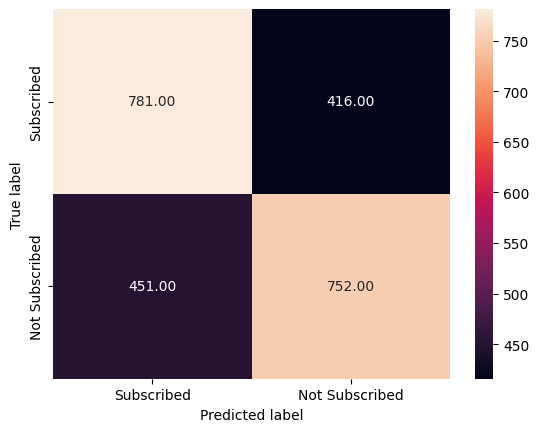

In [33]:
cm = draw_cm( test_y, pred_y )


In [34]:

#ROC AUC Score

## Predicting the probability values for test cases
predict_proba_df = pd.DataFrame( logit.predict_proba( test_X ) )
predict_proba_df.head()
#cm

,0,1
0,0.422739,0.577261
1,0.636116,0.363884
2,0.276280,0.723720
3,0.700521,0.299479
4,0.529814,0.470186


In [35]:
## Initializing the DataFrame with actual class lables
test_results_df = pd.DataFrame( { 'actual': test_y } )
test_results_df = test_results_df.reset_index()
## Assigning the probability values for class label 1
test_results_df['chd_1'] = predict_proba_df.iloc[:,1:2]

In [36]:
test_results_df.head(5)

,index,actual,chd_1
0,3881,1,0.577261
1,290,1,0.363884
2,3614,0,0.723720
3,3460,0,0.299479
4,3676,0,0.470186


In [37]:
# Passing actual class labels and the predicted probability values to compute ROC AUC score.
auc_score = metrics.roc_auc_score( test_results_df.actual, test_results_df.chd_1)
round( float( auc_score ), 2 )

0.68

In [38]:
## The method takes the three following parameters
## model: the classification model
## test_X: X features of the test set
## test_y: actual labels of the test set
## Returns
## - ROC Auc Score
## - FPR and TPRs for different threshold values
def draw_roc_curve( model, test_X, test_y ):
    ## Creating and initializing a results DataFrame with actual labels
    test_results_df = pd.DataFrame( { 'actual': test_y } )
    test_results_df = test_results_df.reset_index()
    # predict the probabilities on the test set
    predict_proba_df = pd.DataFrame( model.predict_proba( test_X ) )
    ## selecting the probabilities that the test example belongs to class 1
    test_results_df['chd_1'] = predict_proba_df.iloc[:,1:2]
    ## Invoke roc_curve() to return the fpr, tpr and threshold values.
    ## threshold values contain values from 0.0 to 1.0
    fpr, tpr, thresholds = metrics.roc_curve( test_results_df.actual,
    test_results_df.chd_1,
    drop_intermediate = False )
    ## Getting the roc auc score by invoking metrics.roc_auc_score method
    auc_score = metrics.roc_auc_score( test_results_df.actual, test_results_df.chd_1 )
    ## Setting the size of the plot
    plt.figure(figsize=(8, 6))
    ## plotting the actual fpr and tpr values
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    ## plotting th diagnoal line from (0,1)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    ## Setting labels and titles
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()
    return auc_score, fpr, tpr, thresholds

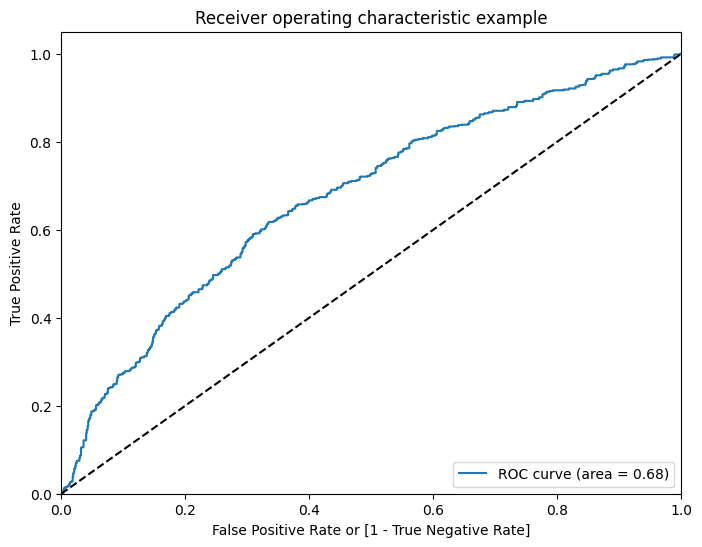

In [39]:
## Invoking draw_roc_curve with the logistic regresson model
_, _, _, _ = draw_roc_curve( logit, test_X, test_y )